## Download YOLO dan Data

In [ ]:
!gdown 1lHCfiR1SpnX-h3kFWFM7KhY6pjNe72MF # yolo
!gdown 1BzOXxgVcicv10L3zZ_hlIqu2tIaPFqDY # excel
!gdown 1Bzjv5yOmjMCjrEnd8cPnOHgod0iY-kD1 # image

Downloading...
From (original): https://drive.google.com/uc?id=1lHCfiR1SpnX-h3kFWFM7KhY6pjNe72MF
From (redirected): https://drive.google.com/uc?id=1lHCfiR1SpnX-h3kFWFM7KhY6pjNe72MF&confirm=t&uuid=e6c697de-f46e-46e5-b23a-bee060132bfc
To: /content/best.pt
100% 114M/114M [00:02<00:00, 52.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BzOXxgVcicv10L3zZ_hlIqu2tIaPFqDY
To: /content/Excel Foto3005.xlsx
100% 69.6k/69.6k [00:00<00:00, 93.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1Bzjv5yOmjMCjrEnd8cPnOHgod0iY-kD1
From (redirected): https://drive.google.com/uc?id=1Bzjv5yOmjMCjrEnd8cPnOHgod0iY-kD1&confirm=t&uuid=d474269e-0b65-40a7-af2d-d9d25d6a6e04
To: /content/Foto 2705.zip
100% 98.1M/98.1M [00:02<00:00, 37.0MB/s]


In [ ]:
import os

!mv 'Excel Foto3005.xlsx' data_labels.xlsx
!mv 'Foto 2705.zip' data_train.zip

## Extract Image

In [ ]:
!unzip data_train.zip -d raw_images

Archive:  data_train.zip
   creating: raw_images/Foto 2705/
  inflating: raw_images/Foto 2705/1 (10).jpeg  
  inflating: raw_images/Foto 2705/1 (1002).jpeg  
  inflating: raw_images/Foto 2705/1 (1009).jpeg  
  inflating: raw_images/Foto 2705/1 (1012).jpeg  
  inflating: raw_images/Foto 2705/1 (1013).jpeg  
  inflating: raw_images/Foto 2705/1 (1017).jpeg  
  inflating: raw_images/Foto 2705/1 (102).jpg  
  inflating: raw_images/Foto 2705/1 (1020).jpeg  
  inflating: raw_images/Foto 2705/1 (1021).jpeg  
  inflating: raw_images/Foto 2705/1 (1024).jpeg  
  inflating: raw_images/Foto 2705/1 (1026).jpeg  
  inflating: raw_images/Foto 2705/1 (1027).jpeg  
  inflating: raw_images/Foto 2705/1 (1028).jpeg  
  inflating: raw_images/Foto 2705/1 (103).jpg  
  inflating: raw_images/Foto 2705/1 (1030).jpeg  
  inflating: raw_images/Foto 2705/1 (1031).jpeg  
  inflating: raw_images/Foto 2705/1 (1032).jpeg  
  inflating: raw_images/Foto 2705/1 (1033).jpeg  
  inflating: raw_images/Foto 2705/1 (1034).jpe

In [ ]:
!pip install ultralytics
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.2 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import pandas as pd
from ultralytics import YOLO
from tqdm import tqdm
import numpy as np

# ================= K O N F I G U R A S I =================
# 1. Path File & Folder
PATH_EXCEL = 'data_labels.xlsx'      # File Excel (Harus ada kolom: Filename, Label1, Label2)
FOLDER_GAMBAR_ASLI = 'raw_images/Foto 2705'    # Folder tempat gambar asli berada
FOLDER_OUTPUT = 'dataset_easyocr'    # Folder output hasil crop
PATH_MODEL_YOLO = 'best.pt'          # Model YOLO Anda (.pt)

# 2. Pengaturan Crop
PADDING = 8  # Menambah margin 8 pixel di sekeliling teks (PENTING untuk OCR)
CONF_THRESHOLD = 0.25 # Batas confidence YOLO
# =========================================================

def process_dataset():
    # Buat folder output
    os.makedirs(FOLDER_OUTPUT, exist_ok=True)

    # Path file ground truth (gt.txt) untuk EasyOCR
    path_gt_txt = os.path.join(FOLDER_OUTPUT, 'gt.txt')

    print("--- MEMULAI PROSES CROP (ATAS - BAWAH) ---")

    # Load Model YOLO
    print(f"Loading YOLO Model: {PATH_MODEL_YOLO}...")
    model = YOLO(PATH_MODEL_YOLO)

    # Load Excel
    print(f"Membaca Excel: {PATH_EXCEL}...")
    df = pd.read_excel(PATH_EXCEL, dtype=str)

    # List untuk menampung baris gt.txt
    gt_lines = []

    # Counter
    sukses = 0
    skip = 0

    # Loop setiap baris di Excel
    for index, row in tqdm(df.iterrows(), total=len(df), desc="Processing"):
        # Ambil data dari kolom (sesuaikan index kolom jika perlu)
        # Asumsi: Kolom 0=NamaFile, Kolom 1=LabelAtas, Kolom 2=LabelBawah
        base_filename = str(row.iloc[0]).strip()
        label_atas = str(row.iloc[1]).strip()
        label_bawah = str(row.iloc[2]).strip()

        # Cek ekstensi file, jika tidak ada tambahkan .jpg (atau sesuaikan)
        if not base_filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            full_filename = base_filename + '.jpg'
        else:
            full_filename = base_filename

        img_path = os.path.join(FOLDER_GAMBAR_ASLI, full_filename)

        # 1. Cek keberadaan file gambar
        if not os.path.exists(img_path):
            skip += 1
            continue

        # 2. Baca Gambar
        img = cv2.imread(img_path)
        if img is None:
            skip += 1
            continue
        h_img, w_img, _ = img.shape

        # 3. Inference YOLO
        try:
            results = model.predict(img_path, conf=CONF_THRESHOLD, verbose=False)
            boxes = results[0].boxes.xyxy.cpu().numpy() # [x1, y1, x2, y2]
        except Exception as e:
            print(f"[Error] Gagal predict {full_filename}: {e}")
            skip += 1
            continue

        # 4. Filter & Validasi Jumlah Box
        if len(boxes) != 2:
            skip += 1
            continue

        sorted_boxes = sorted(boxes, key=lambda b: b[1])

        # Pasangkan dengan label
        pairs = [
            (sorted_boxes[0], label_atas, "top"),    # Box Atas
            (sorted_boxes[1], label_bawah, "bottom") # Box Bawah
        ]

        # 6. Lakukan Crop & Simpan
        for box, label_text, suffix in pairs:
            x1, y1, x2, y2 = map(int, box)

            # Tambah Padding (Agar huruf tidak kepotong pas garis)
            x1 = max(0, x1 - PADDING)
            y1 = max(0, y1 - PADDING)
            x2 = min(w_img, x2 + PADDING)
            y2 = min(h_img, y2 + PADDING)

            # Crop
            crop_img = img[y1:y2, x1:x2]

            # --- BAGIAN YANG DIUBAH ---
            # Pisahkan nama asli dan ekstensinya
            base_name_clean, ext = os.path.splitext(full_filename)

            # Gabungkan nama asli, suffix (top/bottom), dan ekstensi bawaan gambar
            new_filename = f"{base_name_clean}_{suffix}{ext}"
            save_path = os.path.join(FOLDER_OUTPUT, new_filename)
            # --------------------------

            # Simpan Gambar Crop
            cv2.imwrite(save_path, crop_img)

            # Tambahkan ke daftar Ground Truth (Format: filename [tab] label)
            # Pastikan label tidak kosong
            if label_text and str(label_text).lower() != 'nan':
                gt_lines.append(f"{new_filename}\t{label_text}")

        sukses += 1

    # 7. Tulis file gt.txt
    print(f"\nMenulis file gt.txt ({len(gt_lines)} baris)...")
    with open(path_gt_txt, 'w', encoding='utf-8') as f:
        f.write('\n'.join(gt_lines))

    print("\n" + "="*40)
    print(f"SELESAI! Folder Output: {FOLDER_OUTPUT}")
    print(f"Sukses proses: {sukses} gambar ({sukses*2} crops)")
    print(f"Di-Skip      : {skip} gambar (file hilang / deteksi bukan 2 box)")
    print("="*40)

if __name__ == '__main__':
    process_dataset()

--- MEMULAI PROSES CROP (ATAS - BAWAH) ---
Loading YOLO Model: best.pt...
Membaca Excel: data_labels.xlsx...


Processing: 100%|██████████| 1600/1600 [01:31<00:00, 17.55it/s]


Menulis file gt.txt (2908 baris)...

SELESAI! Folder Output: dataset_easyocr
Sukses proses: 1454 gambar (2908 crops)
Di-Skip      : 146 gambar (file hilang / deteksi bukan 2 box)


In [ ]:
!zip -r dataset_easyocr.zip dataset_easyocr

  adding: dataset_easyocr/ (stored 0%)
  adding: dataset_easyocr/SANX3_bottom.jpeg (deflated 8%)
  adding: dataset_easyocr/MET38_top.jpeg (deflated 3%)
  adding: dataset_easyocr/1 (860)_bottom.jpg (deflated 7%)
  adding: dataset_easyocr/1 (792)_bottom.jpg (deflated 5%)
  adding: dataset_easyocr/1 (188)_bottom.jpeg (deflated 4%)
  adding: dataset_easyocr/HE31_bottom.jpeg (deflated 8%)
  adding: dataset_easyocr/1 (557)_bottom.jpg (deflated 8%)
  adding: dataset_easyocr/ELIPS 96_top.jpg (deflated 5%)
  adding: dataset_easyocr/HEXING 26_top.jpg (deflated 5%)
  adding: dataset_easyocr/1 (202)_bottom.jpeg (deflated 3%)
  adding: dataset_easyocr/ELIPS 47_top.jpg (deflated 4%)
  adding: dataset_easyocr/M (5)_bottom.jpg (deflated 6%)
  adding: dataset_easyocr/1 (803)_top.jpg (deflated 5%)
  adding: dataset_easyocr/HEXING 87_top.jpg (deflated 4%)
  adding: dataset_easyocr/1 (395)_top.jpg (deflated 4%)
  adding: dataset_easyocr/1 (664)_top.jpg (deflated 1%)
  adding: dataset_easyocr/1 (67)_top.jp

---

## Evaluasi Easy OCR

In [ ]:
!pip install easyocr jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 15.9 MB/s eta 0:00:00


In [ ]:
import easyocr
import pandas as pd
import os
import time
from jiwer import cer

# --- KONFIGURASI ---
DATA_DIR = 'dataset_easyocr'  # Folder data validasi/test Anda
GT_FILE = os.path.join(DATA_DIR, 'gt.txt')
USE_GPU = True
LANGUAGES = ['en'] # Ganti 'id' jika data bahasa Indonesia spesifik

# Inisialisasi Reader
print("Sedang memuat model EasyOCR...")
reader = easyocr.Reader(LANGUAGES, gpu=USE_GPU)

# Baca Ground Truth
print(f"Membaca data dari {GT_FILE}...")
dataset = []
with open(GT_FILE, 'r', encoding='utf-8') as f:
    lines = f.readlines()
    for line in lines:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            dataset.append({'filename': parts[0], 'ground_truth': parts[1]})

# Mulai Evaluasi
results = []
correct_count = 0
total_images = len(dataset)
start_time = time.time()

print(f"Mulai evaluasi pada {total_images} gambar...")

for idx, data in enumerate(dataset):
    img_path = os.path.join(DATA_DIR, data['filename'])
    ground_truth = data['ground_truth']

    # Cek file ada/tidak
    if not os.path.exists(img_path):
        print(f"Warning: {data['filename']} tidak ditemukan.")
        continue

    # Jalankan EasyOCR (detail=0 hanya ambil teksnya)
    try:
        # allowlist=None (baca semua karakter). Bisa diisi string '0123..' jika mau filter
        prediction_list = reader.readtext(img_path, detail=0)

        # Gabungkan hasil jika terdeteksi pisah baris/kata
        prediction = " ".join(prediction_list)
    except Exception as e:
        prediction = ""
        print(f"Error pada {data['filename']}: {e}")

    # Normalisasi (opsional: lowercase biar fair comparison)
    gt_norm = ground_truth.strip()
    pred_norm = prediction.strip()

    # Hitung Match (Case Sensitive? Kalau tidak, tambahkan .lower())
    is_match = (gt_norm == pred_norm)
    if is_match:
        correct_count += 1

    # Hitung Character Error Rate untuk gambar ini
    # Jika kosong, set error max (1.0)
    if not gt_norm and not pred_norm:
        error_rate = 0.0
    elif not gt_norm or not pred_norm:
        error_rate = 1.0
    else:
        error_rate = cer(gt_norm, pred_norm)

    results.append({
        'filename': data['filename'],
        'ground_truth': gt_norm,
        'prediction': pred_norm,
        'is_match': is_match,
        'cer': error_rate
    })

    if (idx + 1) % 10 == 0:
        print(f"Proses: {idx + 1}/{total_images}...")

# --- HASIL AKHIR ---
end_time = time.time()
df = pd.DataFrame(results)

accuracy = (correct_count / total_images) * 100
avg_cer = df['cer'].mean() * 100

print("\n" + "="*30)
print("HASIL EVALUASI")
print("="*30)
print(f"Total Gambar  : {total_images}")
print(f"Waktu Proses  : {end_time - start_time:.2f} detik")
print(f"Accuracy      : {accuracy:.2f}% (Exact Match)")
print(f"Avg CER       : {avg_cer:.2f}% (Makin rendah makin bagus)")
print("="*30)

# Tampilkan 10 Kesalahan Terburuk (High CER)
print("\n10 Prediksi Salah Terburuk:")
print(df[df['is_match'] == False].sort_values(by='cer', ascending=False).head(10)[['filename', 'ground_truth', 'prediction']])

# Simpan ke CSV untuk dianalisa manual
df.to_csv('hasil_evaluasi_easyocr.csv', index=False)
print("\nDetail lengkap disimpan ke 'hasil_evaluasi_easyocr.csv'")

Sedang memuat model EasyOCR...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteMembaca data dari dataset_easyocr/gt.txt...
Mulai evaluasi pada 2908 gambar...
Proses: 10/2908...
Proses: 20/2908...
Proses: 30/2908...
Proses: 40/2908...
Proses: 50/2908...
Proses: 60/2908...
Proses: 70/2908...
Proses: 80/2908...
Proses: 90/2908...
Proses: 100/2908...
Proses: 110/2908...
Proses: 120/2908...
Proses: 130/2908...
Proses: 140/2908...
Proses: 150/2908...
Proses: 160/2908...
Proses: 170/2908...
Proses: 180/2908...
Proses: 190/2908...
Proses: 200/2908...
Proses: 210/2908...
Proses: 220/2908...
Proses: 230/2908...
Proses: 240/2908...
Proses: 250/2908...
Proses: 260/2908...
Proses: 270/2908...
Proses: 280/2908...
Proses: 290/2908...
Proses: 300/2908...
Proses: 310/2908...
Proses: 320/2908...
Proses: 330/2908...
Proses: 340/2908...
Proses: 350/2908...
Proses: 360/2908...
Proses: 370/2908...
Proses: 380/2908...
Proses: 390/2908...
Proses: 400/2908...
Proses: 410/2908...
Proses: 420/2908...
Proses: 430/

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the evaluation results CSV
df_eval = pd.read_csv('hasil_evaluasi_easyocr.csv')

# Define the classes (digits 0-9)
classes = [str(i) for i in range(10)]
class_to_idx = {char: i for i, char in enumerate(classes)}

# Initialize a confusion matrix with zeros (10x10 for digits 0-9)
conf_matrix = np.zeros((len(classes), len(classes)), dtype=int)

# Iterate through each row to populate the confusion matrix
for index, row in df_eval.iterrows():
    ground_truth = str(row['ground_truth'])
    prediction = str(row['prediction'])

    # Compare character by character up to the minimum length of the two strings
    min_len = min(len(ground_truth), len(prediction))

    for i in range(min_len):
        gt_char = ground_truth[i]
        pred_char = prediction[i]

        # Only consider digit characters for the confusion matrix
        if gt_char in class_to_idx and pred_char in class_to_idx:
            gt_idx = class_to_idx[gt_char]
            pred_idx = class_to_idx[pred_char]
            conf_matrix[gt_idx][pred_idx] += 1

# Display the confusion matrix numerically
print("Confusion Matrix for Digits (0-9):")
print(conf_matrix)

# Calculate overall digit accuracy based on compared positions
total_matched_digits = np.sum(conf_matrix)
correctly_predicted_digits = np.trace(conf_matrix) # Sum of diagonal elements
digit_accuracy = (correctly_predicted_digits / total_matched_digits) * 100 if total_matched_digits > 0 else 0

print(f"\nTotal digit characters compared: {total_matched_digits}")
print(f"Correctly predicted digit characters: {correctly_predicted_digits}")
print(f"Overall Digit Accuracy (based on overlapping digit characters): {digit_accuracy:.2f}%")


Confusion Matrix for Digits (0-9):
[[1090  103   79   56   48   59   61   52   49   49]
 [ 265 1535  123   85  179   75   66  106   66   63]
 [ 354  161 1471   79   89  274  126  132   50   96]
 [ 166   55  104  590   57   54   37   55   66   35]
 [ 157   60   64   60  769   65  104   47   47   52]
 [ 148   76  290   64   71 1408  103   57   55   68]
 [ 151   74  144   64   89  177  833   64  108   29]
 [ 112   54   42   33   44   41   60  489   37   41]
 [ 157   71   58   51   46   48   51   35  442   38]
 [ 118   51   63   47   61   93   53   50   47  901]]

Total digit characters compared: 17192
Correctly predicted digit characters: 9528
Overall Digit Accuracy (based on overlapping digit characters): 55.42%


Confusion matrix heatmap saved as 'confusion_matrix_heatmap_high_dpi.png' with 400 DPI.


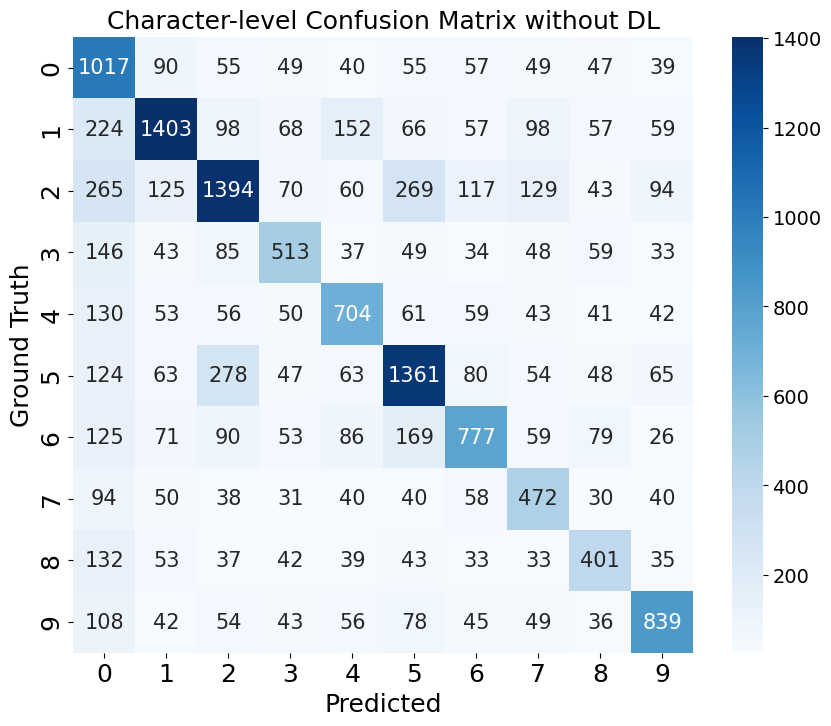

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the confusion matrix as a heatmap
fig = plt.figure(figsize=(10, 8)) # Reverted figure size to 10x8
ax = sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            annot_kws={"size": 15}) # Enlarged annotation font size
plt.xlabel('Predicted', fontsize=18) # Enlarged x-label font size
plt.ylabel('Ground Truth', fontsize=18) # Enlarged y-label font size
plt.title('Character-level Confusion Matrix without DL', fontsize=18) # Enlarged title font size

# Increase font size for tick labels on x and y axes
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)

# Get the colorbar object and set its label font size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14) # Set font size for colorbar tick labels

# Save the figure with a higher DPI before showing
fig.savefig('confusion_matrix_heatmap_high_dpi.png', dpi=400, bbox_inches='tight')
print("Confusion matrix heatmap saved as 'confusion_matrix_heatmap_high_dpi.png' with 400 DPI.")

plt.show()

In [ ]:
# This cell is no longer needed as saving is integrated into the plotting cell.

In [ ]:
import numpy as np
import pandas as pd

# Assuming conf_matrix is already defined from the previous step
# If not, you would need to load it or redefine it here.
# Example: conf_matrix = np.array([...])

# Get the number of classes (digits 0-9)
num_classes = conf_matrix.shape[0]
classes = [str(i) for i in range(num_classes)]

# Initialize lists to store metrics for each class
precision_per_class = []
recall_per_class = []
f1_per_class = []
accuracy_per_class = []

# Calculate metrics for each class
for i in range(num_classes):
    TP = conf_matrix[i, i]
    FP = np.sum(conf_matrix[:, i]) - TP
    FN = np.sum(conf_matrix[i, :]) - TP
    TN = np.sum(conf_matrix) - (TP + FP + FN)

    # Handle division by zero for precision and recall
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (TP + TN) / np.sum(conf_matrix) if np.sum(conf_matrix) > 0 else 0

    precision_per_class.append(precision)
    recall_per_class.append(recall)
    f1_per_class.append(f1)
    accuracy_per_class.append(accuracy)

# Create a DataFrame for better readability
metrics_df = pd.DataFrame({
    'Class': classes,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Accuracy': accuracy_per_class
})

print("Metrics per Class (Digit):")
display(metrics_df)

# Calculate macro averages
macro_precision = np.mean(precision_per_class)
macro_recall = np.mean(recall_per_class)
macro_f1 = np.mean(f1_per_class)

# Overall Accuracy (already calculated in the previous step as digit_accuracy)
# Re-calculating for completeness, but it should match digit_accuracy
total_matched_digits = np.sum(conf_matrix)
correctly_predicted_digits = np.trace(conf_matrix)
overall_accuracy = (correctly_predicted_digits / total_matched_digits) * 100 if total_matched_digits > 0 else 0

print("\nOverall (Macro-Averaged) Metrics:")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")
print(f"Macro F1-Score:  {macro_f1:.4f}")
print(f"Overall Accuracy (Character Level): {overall_accuracy:.2f}%")


Metrics per Class (Digit):


,Class,Precision,Recall,F1-Score,Accuracy
0,0,0.430021,0.678905,0.526534,0.881549
1,1,0.703964,0.614812,0.656374,0.904864
2,2,0.637986,0.543258,0.586824,0.872871
3,3,0.531056,0.489971,0.509687,0.936079
4,4,0.551292,0.568200,0.559618,0.928243
5,5,0.621178,0.623454,0.622314,0.893012
6,6,0.589977,0.506189,0.544881,0.915938
7,7,0.456480,0.528555,0.489881,0.936338
8,8,0.476813,0.472877,0.474837,0.942556
9,9,0.659591,0.621481,0.639969,0.938864



Overall (Macro-Averaged) Metrics:
Macro Precision: 0.5658
Macro Recall:    0.5648
Macro F1-Score:  0.5611
Overall Accuracy (Character Level): 57.52%
